In [1]:
RETRAIN = False


# PatchCore + WideResNet50-2 Multilayer (All-in-One)

This notebook is designed to run locally from the repository on any machine with the project dependencies installed.

Place `LSWMD.pkl` somewhere accessible locally, then run all cells. The notebook will prepare the shared `64x64` split, fit a multilayer `WideResNet50-2` PatchCore model using `layer2 + layer3`, run a small critical sweep, and save repo-compatible summaries.


## Submission Context

- Dataset notebook: `data/dataset/x64/benchmark_50k_5pct/notebook.ipynb`
- Dataset config: `data/dataset/x64/benchmark_50k_5pct/data_config.toml`
- Experiment config: `embedded in notebook`
- Artifact root: `experiments/anomaly_detection/patchcore/wideresnet50/x64/main/artifacts/`
- Notes:
  - This all-in-one notebook still rebuilds its dataset internally for portability, but it should stay aligned with the curated x64 benchmark branch.


In [2]:
from pathlib import Path

def resolve_repo_root(start: Path | None = None) -> Path:
    start_path = (start or Path.cwd()).resolve()
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "experiments").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError("Could not locate the repository root.")

REPO_ROOT = resolve_repo_root()

RAW_PICKLE = "LSWMD.pkl"  # leave blank to auto-find LSWMD.pkl
OUTPUT_DIR = str(
    (
        REPO_ROOT
        / "experiments/anomaly_detection/patchcore/wideresnet50/x64/main/artifacts/patchcore_wideresnet50_multilayer"
    ).resolve()
)
IMAGE_SIZE = 64
NORMAL_LIMIT = 50_000
TEST_DEFECT_FRACTION = 0.05
BATCH_SIZE = 64
NUM_WORKERS = 0
DEVICE = "auto"
SEED = 42
TEACHER_INPUT_SIZE = 224
TEACHER_LAYERS = ["layer2", "layer3"]
PRETRAINED = True
FREEZE_BACKBONE = True
NORMALIZE_IMAGENET = True
THRESHOLD_QUANTILE = 0.95
QUERY_CHUNK_SIZE = 1024
MEMORY_CHUNK_SIZE = 4096
SWEEP_VARIANTS = [
    {"name": "mean_mb20k", "memory_bank_size": 20_000, "reduction": "mean", "topk_ratio": 0.10},
    {"name": "mean_mb50k", "memory_bank_size": 50_000, "reduction": "mean", "topk_ratio": 0.10},
    {"name": "topk_mb50k_r010", "memory_bank_size": 50_000, "reduction": "topk_mean", "topk_ratio": 0.10},
    {"name": "topk_mb50k_r015", "memory_bank_size": 50_000, "reduction": "topk_mean", "topk_ratio": 0.15},
]


In [3]:
from __future__ import annotations

import json
import math
import pickle
import random
import sys
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas.core.indexes as core_indexes
import torch
import torch.nn.functional as F
from sklearn.metrics import average_precision_score, confusion_matrix, precision_recall_curve, precision_score, recall_score, roc_auc_score
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset
from tqdm.auto import tqdm
from torchvision.models import Wide_ResNet50_2_Weights, wide_resnet50_2

LABEL_NORMAL = "none"
LABEL_DEFECT = "pattern"

def set_seed(seed: int) -> None:
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

def resolve_device(device_name: str) -> torch.device:
    return torch.device("cuda" if device_name == "auto" and torch.cuda.is_available() else device_name)

def read_legacy_pickle(path: Path) -> pd.DataFrame:
    sys.modules["pandas.indexes"] = core_indexes
    with path.open("rb") as handle: return pickle.load(handle, encoding="latin1")

def unwrap_legacy_value(value: Any) -> str:
    if value is None: return ""
    if hasattr(value, "size") and getattr(value, "size") == 0: return ""
    if hasattr(value, "tolist"): value = value.tolist()
    while isinstance(value, list) and len(value) == 1: value = value[0]
    return str(value).strip()

def normalize_map(wafer_map: np.ndarray, image_size: int) -> np.ndarray:
    wafer_map = np.asarray(wafer_map, dtype=np.float32) / 2.0
    tensor = torch.from_numpy(wafer_map).unsqueeze(0).unsqueeze(0)
    return F.interpolate(tensor, size=(image_size, image_size), mode="nearest").squeeze(0).squeeze(0).numpy()

def infer_label_from_row(row: pd.Series) -> str | None:
    failure = unwrap_legacy_value(row.get("failureType", "")).lower()
    if failure == "none": return LABEL_NORMAL
    if failure: return LABEL_DEFECT
    return None

def split_normals(normal_df: pd.DataFrame, seed: int) -> pd.DataFrame:
    shuffled = normal_df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n = len(shuffled); train_end = int(0.8 * n); val_end = int(0.9 * n)
    shuffled.loc[: train_end - 1, "split"] = "train"; shuffled.loc[train_end: val_end - 1, "split"] = "val"; shuffled.loc[val_end:, "split"] = "test"
    return shuffled

def sample_test_defects(defect_df: pd.DataFrame, normal_df: pd.DataFrame, fraction: float, seed: int) -> pd.DataFrame:
    requested = max(1, int(round(int((normal_df["split"] == "test").sum()) * fraction)))
    sampled = defect_df.sample(n=min(requested, len(defect_df)), random_state=seed).copy(); sampled["split"] = "test"; return sampled

def auto_find_raw_pickle(explicit_path: str) -> Path:
    if explicit_path:
        path = Path(explicit_path)
        if not path.exists(): raise FileNotFoundError(f"Raw pickle not found: {path}")
        return path
    for root in [Path.cwd(), Path("/root"), Path("/mnt/data"), Path("/workspace")]:
        if root.exists():
            matches = sorted(root.rglob("LSWMD.pkl"))
            if matches: return matches[0]
    raise FileNotFoundError("Could not find LSWMD.pkl. Pass RAW_PICKLE explicitly.")

def prepare_dataset(raw_pickle: Path, output_dir: Path, image_size: int, normal_limit: int, test_defect_fraction: float, seed: int) -> Path:
    processed_dir = output_dir / "processed"; arrays_dir = processed_dir / "arrays"; metadata_path = processed_dir / "metadata_50k_5pct.csv"
    if metadata_path.exists(): print(f"Reusing processed metadata: {metadata_path}"); return metadata_path
    processed_dir.mkdir(parents=True, exist_ok=True); arrays_dir.mkdir(parents=True, exist_ok=True)
    df = read_legacy_pickle(raw_pickle).copy(); df["failureTypeText"] = df["failureType"].map(unwrap_legacy_value); df["trianTestLabelText"] = df["trianTestLabel"].map(unwrap_legacy_value); df["label"] = df.apply(infer_label_from_row, axis=1); df = df[df["label"].notna()].reset_index(drop=True)
    normal_df = df[df["label"] == LABEL_NORMAL].copy(); defect_df = df[df["label"] == LABEL_DEFECT].copy(); normal_df = normal_df.sample(n=min(normal_limit, len(normal_df)), random_state=seed); normal_df = split_normals(normal_df, seed); defect_df = sample_test_defects(defect_df, normal_df, test_defect_fraction, seed)
    export_df = pd.concat([normal_df, defect_df], ignore_index=True); print(f"Preparing arrays | normals={len(normal_df)} | defects={len(defect_df)} | total={len(export_df)}")
    records = []
    for row_index, row in tqdm(export_df.iterrows(), total=len(export_df), desc="Preparing arrays"):
        array_path = arrays_dir / f"wafer_{row_index:07d}.npy"; raw_map = np.asarray(row["waferMap"]); np.save(array_path, normalize_map(raw_map, image_size=image_size))
        records.append({"array_path": str(array_path), "label": row["label"], "defect_type": row["failureTypeText"] or "unlabeled", "is_anomaly": int(row["label"] == LABEL_DEFECT), "split": row["split"], "source_split": row["trianTestLabelText"] or "unlabeled", "original_height": int(raw_map.shape[0]), "original_width": int(raw_map.shape[1])})
    pd.DataFrame(records).to_csv(metadata_path, index=False); print(f"Saved processed metadata: {metadata_path}"); return metadata_path

class WaferArrayDataset(Dataset):
    def __init__(self, metadata_csv: Path, split: str) -> None:
        self.metadata = pd.read_csv(metadata_csv); self.metadata = self.metadata[self.metadata["split"] == split].reset_index(drop=True)
    def __len__(self) -> int: return len(self.metadata)
    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        row = self.metadata.iloc[index]; wafer_map = np.load(row["array_path"]).astype(np.float32)
        return torch.from_numpy(wafer_map).unsqueeze(0), torch.tensor(int(row["is_anomaly"]), dtype=torch.long)

def summarize_threshold_metrics(labels: np.ndarray, scores: np.ndarray, threshold: float) -> dict[str, float | int | list[list[int]]]:
    predicted = (scores >= threshold).astype(int)
    precision = float(precision_score(labels, predicted, zero_division=0)); recall = float(recall_score(labels, predicted, zero_division=0)); f1 = float(0.0 if precision + recall == 0 else 2.0 * precision * recall / (precision + recall))
    return {"threshold": float(threshold), "precision": precision, "recall": recall, "f1": f1, "auroc": float(roc_auc_score(labels, scores)), "auprc": float(average_precision_score(labels, scores)), "predicted_anomalies": int(predicted.sum()), "confusion_matrix": confusion_matrix(labels, predicted, labels=[0, 1]).tolist()}

def sweep_threshold_metrics(
    test_labels: np.ndarray,
    test_scores: np.ndarray,
) -> tuple[pd.DataFrame, dict]:
    """Full threshold sweep using precision_recall_curve (true upper bound)."""
    prec_curve, rec_curve, thresholds = precision_recall_curve(test_labels, test_scores)
    sweep_df = pd.DataFrame({
        "threshold": thresholds,
        "precision": prec_curve[:-1],
        "recall":    rec_curve[:-1],
    })
    sweep_df["f1"] = (
        2 * sweep_df["precision"] * sweep_df["recall"]
        / (sweep_df["precision"] + sweep_df["recall"] + 1e-12)
    )
    sweep_df["predicted_anomalies"] = [(test_scores >= t).sum() for t in sweep_df["threshold"]]
    best_row = sweep_df.loc[sweep_df["f1"].idxmax()]
    best_summary = {
        "threshold": float(best_row["threshold"]),
        "precision": float(best_row["precision"]),
        "recall":    float(best_row["recall"]),
        "f1":        float(best_row["f1"]),
        "predicted_anomalies": int(best_row["predicted_anomalies"]),
    }
    return sweep_df, best_summary

def _teacher_feature_dims(layer_names: list[str]) -> dict[str, int]: return {"layer1": 256, "layer2": 512, "layer3": 1024, "layer4": 2048} | {}
def _teacher_spatial_size(input_size: int, layer_names: list[str]) -> int:
    downsample = {"layer1": 4, "layer2": 8, "layer3": 16, "layer4": 32}
    return max(1, input_size // min(downsample[name] for name in layer_names))

class WideResNet50_2MultiLayerExtractor(nn.Module):
    def __init__(self, teacher_layers: list[str], pretrained: bool = True, input_size: int = 224, freeze_backbone: bool = True, normalize_imagenet: bool = True) -> None:
        super().__init__(); self.teacher_layers = [str(x).lower() for x in teacher_layers]
        weights = Wide_ResNet50_2_Weights.DEFAULT if pretrained else None; backbone = wide_resnet50_2(weights=weights)
        original_conv = backbone.conv1; adapted_conv = nn.Conv2d(1, original_conv.out_channels, kernel_size=original_conv.kernel_size, stride=original_conv.stride, padding=original_conv.padding, bias=False)
        with torch.no_grad(): adapted_conv.weight.copy_(original_conv.weight.mean(dim=1, keepdim=True))
        backbone.conv1 = adapted_conv; self.stem = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool); self.layer1 = backbone.layer1; self.layer2 = backbone.layer2; self.layer3 = backbone.layer3; self.layer4 = backbone.layer4
        self.input_size = int(input_size); self.normalize_imagenet = bool(normalize_imagenet); self.register_buffer("image_mean", torch.tensor([0.4490], dtype=torch.float32).view(1, 1, 1, 1)); self.register_buffer("image_std", torch.tensor([0.2260], dtype=torch.float32).view(1, 1, 1, 1))
        dim_map = {"layer1": 256, "layer2": 512, "layer3": 1024, "layer4": 2048}; self.feature_dims = {name: dim_map[name] for name in self.teacher_layers}; self.output_spatial = _teacher_spatial_size(self.input_size, self.teacher_layers)
        if freeze_backbone:
            for parameter in self.parameters(): parameter.requires_grad = False
    def preprocess(self, x: torch.Tensor) -> torch.Tensor:
        if x.shape[-1] != self.input_size or x.shape[-2] != self.input_size: x = F.interpolate(x, size=(self.input_size, self.input_size), mode="bilinear", align_corners=False)
        return (x - self.image_mean) / self.image_std if self.normalize_imagenet else x
    def forward_feature_maps(self, x: torch.Tensor) -> dict[str, torch.Tensor]:
        outputs = {}; x = self.preprocess(x); x = self.stem(x); x = self.layer1(x); 
        if "layer1" in self.teacher_layers: outputs["layer1"] = x
        x = self.layer2(x); 
        if "layer2" in self.teacher_layers: outputs["layer2"] = x
        x = self.layer3(x); 
        if "layer3" in self.teacher_layers: outputs["layer3"] = x
        x = self.layer4(x); 
        if "layer4" in self.teacher_layers: outputs["layer4"] = x
        return outputs

class MultiLayerPatchCoreModel(nn.Module):
    def __init__(self, image_size: int, teacher_layers: list[str], memory_bank_size: int, reduction: str, topk_ratio: float, pretrained: bool = True, freeze_backbone: bool = True, backbone_input_size: int = 224, normalize_imagenet: bool = True, query_chunk_size: int = 1024, memory_chunk_size: int = 4096) -> None:
        super().__init__(); self.teacher_layers = [str(x).lower() for x in teacher_layers]; self.memory_bank_size = int(memory_bank_size); self.reduction = str(reduction); self.topk_ratio = float(topk_ratio); self.query_chunk_size = int(query_chunk_size); self.memory_chunk_size = int(memory_chunk_size)
        self.teacher = WideResNet50_2MultiLayerExtractor(self.teacher_layers, pretrained=pretrained, input_size=backbone_input_size, freeze_backbone=freeze_backbone, normalize_imagenet=normalize_imagenet)
        self.feature_dim = sum(self.teacher.feature_dims.values()); self.reduced_spatial = self.teacher.output_spatial; self.register_buffer("memory_bank", torch.empty(0, self.feature_dim))
    @property
    def patches_per_image(self) -> int: return self.reduced_spatial * self.reduced_spatial
    def patch_embeddings(self, x: torch.Tensor) -> torch.Tensor:
        feature_maps = self.teacher.forward_feature_maps(x); target_size = max(feature_map.shape[-1] for feature_map in feature_maps.values()); embeddings = []
        for layer_name in self.teacher_layers:
            feature_map = feature_maps[layer_name]
            if feature_map.shape[-1] != target_size or feature_map.shape[-2] != target_size: feature_map = F.interpolate(feature_map, size=(target_size, target_size), mode="bilinear", align_corners=False)
            layer_embeddings = feature_map.permute(0, 2, 3, 1).reshape(x.shape[0], -1, feature_map.shape[1]); embeddings.append(F.normalize(layer_embeddings, p=2, dim=-1))
        return F.normalize(torch.cat(embeddings, dim=-1), p=2, dim=-1)
    def set_memory_bank(self, memory_bank: torch.Tensor) -> None: self.memory_bank = F.normalize(memory_bank.to(dtype=torch.float32), p=2, dim=1).to(device=self.memory_bank.device, dtype=self.memory_bank.dtype)
    def nearest_patch_distances(self, patch_embeddings: torch.Tensor) -> torch.Tensor:
        batch_size, patch_count, _ = patch_embeddings.shape; flat_queries = patch_embeddings.reshape(-1, self.feature_dim); all_mins = []
        for query_start in range(0, flat_queries.shape[0], self.query_chunk_size):
            query_chunk = flat_queries[query_start: query_start + self.query_chunk_size]; chunk_best = None
            for memory_start in range(0, self.memory_bank.shape[0], self.memory_chunk_size):
                memory_chunk = self.memory_bank[memory_start: memory_start + self.memory_chunk_size]; distances = torch.cdist(query_chunk, memory_chunk); current_best = distances.min(dim=1).values; chunk_best = current_best if chunk_best is None else torch.minimum(chunk_best, current_best)
            all_mins.append(chunk_best)
        return torch.cat(all_mins, dim=0).reshape(batch_size, patch_count)
    def reduce_patch_distances(self, patch_distances: torch.Tensor) -> torch.Tensor:
        if self.reduction == "max": return patch_distances.max(dim=1).values
        if self.reduction == "mean": return patch_distances.mean(dim=1)
        topk = max(1, int(math.ceil(patch_distances.shape[1] * self.topk_ratio))); return torch.topk(patch_distances, k=topk, dim=1).values.mean(dim=1)
    def forward(self, x: torch.Tensor) -> torch.Tensor: return self.reduce_patch_distances(self.nearest_patch_distances(self.patch_embeddings(x)))

def sample_memory_indices(dataset_size: int, memory_bank_size: int, patches_per_image: int, seed: int) -> np.ndarray:
    image_count = min(dataset_size, max(1, math.ceil(memory_bank_size / patches_per_image))); rng = np.random.default_rng(seed); return np.sort(rng.choice(dataset_size, size=image_count, replace=False))
def build_memory_subset(dataset: Dataset, memory_bank_size: int, patches_per_image: int, seed: int) -> Subset: return Subset(dataset, sample_memory_indices(len(dataset), memory_bank_size, patches_per_image, seed).tolist())
def collect_memory_bank(model: MultiLayerPatchCoreModel, dataloader: DataLoader, device: torch.device, target_size: int, seed: int) -> torch.Tensor:
    patch_batches = []; model.eval()
    with torch.inference_mode():
        for inputs, labels in tqdm(dataloader, desc="Collect memory bank"):
            inputs = inputs.to(device); labels = labels.to(device); normal_mask = labels == 0
            if not torch.any(normal_mask): continue
            patch_batches.append(model.patch_embeddings(inputs[normal_mask]).reshape(-1, model.feature_dim).cpu())
    memory_bank = torch.cat(patch_batches, dim=0)
    if memory_bank.shape[0] > target_size:
        generator = torch.Generator().manual_seed(seed); keep = torch.randperm(memory_bank.shape[0], generator=generator)[:target_size]; memory_bank = memory_bank[keep]
    return memory_bank
def collect_scores(model: MultiLayerPatchCoreModel, dataloader: DataLoader, device: torch.device) -> pd.DataFrame:
    rows = []; model.eval()
    with torch.inference_mode():
        for inputs, labels in tqdm(dataloader, desc="Score batches"):
            scores = model(inputs.to(device))
            for score, label in zip(scores.cpu().tolist(), labels.tolist()): rows.append({"score": float(score), "is_anomaly": int(label)})
    return pd.DataFrame(rows)

def build_patchcore_checkpoint(model: MultiLayerPatchCoreModel, variant: dict[str, Any], threshold: float) -> dict[str, Any]:
    return {
        "name": str(variant["name"]),
        "teacher_backbone": "wideresnet50_2",
        "teacher_layers": list(TEACHER_LAYERS),
        "image_size": int(IMAGE_SIZE),
        "backbone_input_size": int(TEACHER_INPUT_SIZE),
        "pretrained": bool(PRETRAINED),
        "freeze_backbone": bool(FREEZE_BACKBONE),
        "normalize_imagenet": bool(NORMALIZE_IMAGENET),
        "memory_bank_size": int(variant["memory_bank_size"]),
        "reduction": str(variant["reduction"]),
        "topk_ratio": float(variant["topk_ratio"]),
        "query_chunk_size": int(QUERY_CHUNK_SIZE),
        "memory_chunk_size": int(MEMORY_CHUNK_SIZE),
        "feature_dim": int(model.feature_dim),
        "patches_per_image": int(model.patches_per_image),
        "threshold_quantile": float(THRESHOLD_QUANTILE),
        "threshold": float(threshold),
        "memory_bank": model.memory_bank.detach().cpu(),
    }

def save_patchcore_checkpoint(variant_output_dir: Path, model: MultiLayerPatchCoreModel, variant: dict[str, Any], threshold: float) -> Path:
    checkpoint_path = variant_output_dir / "patchcore_checkpoint.pt"
    torch.save(build_patchcore_checkpoint(model, variant, threshold), checkpoint_path)
    return checkpoint_path

In [4]:
CONFIG = {
    "run": {"output_dir": OUTPUT_DIR, "seed": SEED},
    "data": {"image_size": IMAGE_SIZE, "normal_limit": NORMAL_LIMIT, "test_defect_fraction": TEST_DEFECT_FRACTION, "batch_size": BATCH_SIZE, "num_workers": NUM_WORKERS},
    "model": {"backbone_type": "wideresnet50_2", "teacher_layers": TEACHER_LAYERS, "pretrained": PRETRAINED, "freeze_backbone": FREEZE_BACKBONE, "backbone_input_size": TEACHER_INPUT_SIZE, "normalize_imagenet": NORMALIZE_IMAGENET, "query_chunk_size": QUERY_CHUNK_SIZE, "memory_chunk_size": MEMORY_CHUNK_SIZE},
    "scoring": {"threshold_quantile": THRESHOLD_QUANTILE},
    "sweep_variants": SWEEP_VARIANTS,
}

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") if DEVICE == "auto" else resolve_device(DEVICE)
output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)
(output_dir / "config.json").write_text(json.dumps(CONFIG, indent=2), encoding="utf-8")
sweep_results_csv = output_dir / "patchcore_sweep_results.csv"
follow_up_csv = output_dir / "patchcore_follow_up_sweep_results.csv"
dataset_ready = False
sweep_ready = False
follow_up_ready = False
if RETRAIN:
    print('[WARNING] RETRAIN=True remains available for this notebook, but this runtime-fix pass only supports artifact-backed execution.')
elif sweep_results_csv.exists():
    sweep_results_df = pd.read_csv(sweep_results_csv)
    best_row = sweep_results_df.iloc[0].to_dict()
    sweep_ready = not sweep_results_df.empty
    print(f"Loaded saved main-sweep results from {sweep_results_csv}")
    if follow_up_csv.exists():
        follow_up_results_df = pd.read_csv(follow_up_csv)
        follow_up_ready = not follow_up_results_df.empty
        print(f"Loaded saved follow-up results from {follow_up_csv}")
    else:
        follow_up_results_df = pd.DataFrame()
    print(f"Using device: {device}")
else:
    print('[WARNING] Saved WRN50 PatchCore sweep artifacts are missing. Training-backed cells will be skipped in this notebook run.')
    sweep_results_df = pd.DataFrame()
    follow_up_results_df = pd.DataFrame()


Loaded saved main-sweep results from C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\wideresnet50\x64\main\artifacts\patchcore_wideresnet50_multilayer\patchcore_sweep_results.csv
Loaded saved follow-up results from C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\wideresnet50\x64\main\artifacts\patchcore_wideresnet50_multilayer\patchcore_follow_up_sweep_results.csv
Using device: cuda


In [5]:
if not (sweep_ready):
    print('[WARNING] Saved WRN50 PatchCore sweep artifacts are unavailable for this notebook run.')
else:
    sweep_results_csv = output_dir / "patchcore_sweep_results.csv"

    if not RETRAIN and sweep_results_csv.exists():
        sweep_results_df = pd.read_csv(sweep_results_csv)
        best_row = sweep_results_df.iloc[0].to_dict()
        print(f"Loaded saved main-sweep results from {sweep_results_csv}")
        print("Set RETRAIN = True to rebuild the memory bank for all variants.")
        display(sweep_results_df)
    else:
        sweep_rows = []
        for variant in SWEEP_VARIANTS:
            print(f"\n=== PatchCore variant: {variant['name']} ===")
            model = MultiLayerPatchCoreModel(image_size=IMAGE_SIZE, teacher_layers=TEACHER_LAYERS, memory_bank_size=variant["memory_bank_size"], reduction=variant["reduction"], topk_ratio=variant["topk_ratio"], pretrained=PRETRAINED, freeze_backbone=FREEZE_BACKBONE, backbone_input_size=TEACHER_INPUT_SIZE, normalize_imagenet=NORMALIZE_IMAGENET, query_chunk_size=QUERY_CHUNK_SIZE, memory_chunk_size=MEMORY_CHUNK_SIZE).to(device)
            memory_subset = build_memory_subset(train_dataset, variant["memory_bank_size"], model.patches_per_image, SEED)
            memory_loader = DataLoader(memory_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
            model.set_memory_bank(collect_memory_bank(model, memory_loader, device, target_size=variant["memory_bank_size"], seed=SEED))
            val_scores_df = collect_scores(model, val_loader, device); test_scores_df = collect_scores(model, test_loader, device)
            threshold = float(val_scores_df.loc[val_scores_df["is_anomaly"] == 0, "score"].quantile(THRESHOLD_QUANTILE))
            labels = test_scores_df["is_anomaly"].to_numpy(); scores = test_scores_df["score"].to_numpy(); metrics = summarize_threshold_metrics(labels, scores, threshold); threshold_sweep_df, best_sweep = sweep_threshold_metrics(labels, scores)
            variant_output_dir = output_dir / variant["name"]; variant_output_dir.mkdir(parents=True, exist_ok=True)
            val_scores_df.to_csv(variant_output_dir / "val_scores.csv", index=False); test_scores_df.to_csv(variant_output_dir / "test_scores.csv", index=False); threshold_sweep_df.to_csv(variant_output_dir / "threshold_sweep.csv", index=False)
            checkpoint_path = save_patchcore_checkpoint(variant_output_dir, model, variant, threshold)
            summary = {"name": variant["name"], "teacher_backbone": "wideresnet50_2", "teacher_layers": TEACHER_LAYERS, "memory_bank_size": int(variant["memory_bank_size"]), "memory_subset_images": int(len(memory_subset)), "patches_per_image": int(model.patches_per_image), "feature_dim": int(model.feature_dim), "reduction": variant["reduction"], "topk_ratio": float(variant["topk_ratio"]), "threshold_quantile": THRESHOLD_QUANTILE, "threshold": float(threshold), "checkpoint_path": str(checkpoint_path), "metrics_at_validation_threshold": metrics, "best_threshold_sweep": {"threshold": float(best_sweep["threshold"]), "precision": float(best_sweep["precision"]), "recall": float(best_sweep["recall"]), "f1": float(best_sweep["f1"]), "predicted_anomalies": float(best_sweep["predicted_anomalies"])}}
            (variant_output_dir / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
            row = {"name": variant["name"], "memory_bank_size": int(variant["memory_bank_size"]), "memory_subset_images": int(len(memory_subset)), "patches_per_image": int(model.patches_per_image), "feature_dim": int(model.feature_dim), "reduction": variant["reduction"], "topk_ratio": float(variant["topk_ratio"]), "threshold": float(threshold), "precision": float(metrics["precision"]), "recall": float(metrics["recall"]), "f1": float(metrics["f1"]), "auroc": float(metrics["auroc"]), "auprc": float(metrics["auprc"]), "best_sweep_threshold": float(best_sweep["threshold"]), "best_sweep_precision": float(best_sweep["precision"]), "best_sweep_recall": float(best_sweep["recall"]), "best_sweep_f1": float(best_sweep["f1"]), "predicted_anomalies": int(metrics["predicted_anomalies"]), "output_dir": str(variant_output_dir), "checkpoint_path": str(checkpoint_path)}
            sweep_rows.append(row)
            print(row)
        sweep_results_df = pd.DataFrame(sweep_rows).sort_values(["f1", "auroc"], ascending=False).reset_index(drop=True)
        sweep_results_df.to_csv(output_dir / "patchcore_sweep_results.csv", index=False)
        best_row = sweep_results_df.iloc[0].to_dict()
        (output_dir / "patchcore_sweep_summary.json").write_text(json.dumps({"sweep_variants": [variant["name"] for variant in SWEEP_VARIANTS], "base_output_dir": str(output_dir), "teacher_backbone": "wideresnet50_2", "teacher_layers": TEACHER_LAYERS, "best_variant": best_row}, indent=2), encoding="utf-8")
        display(sweep_results_df)


Loaded saved main-sweep results from C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\wideresnet50\x64\main\artifacts\patchcore_wideresnet50_multilayer\patchcore_sweep_results.csv
Set RETRAIN = True to rebuild the memory bank for all variants.


,name,memory_bank_size,memory_subset_images,patches_per_image,feature_dim,reduction,topk_ratio,threshold,precision,recall,f1,auroc,auprc,best_sweep_threshold,best_sweep_precision,best_sweep_recall,best_sweep_f1,predicted_anomalies,output_dir,checkpoint_path
0,topk_mb50k_r010,50000,64,784,1536,topk_mean,0.10,0.529660,0.421546,0.720,0.531758,0.916943,0.561855,0.548772,0.614035,0.560,0.585774,427,experiments/anomaly_detection/patchcore/widere...,experiments/anomaly_detection/patchcore/widere...
1,topk_mb50k_r015,50000,64,784,1536,topk_mean,0.15,0.514512,0.420673,0.700,0.525526,0.911559,0.548919,0.532648,0.620087,0.568,0.592902,416,experiments/anomaly_detection/patchcore/widere...,experiments/anomaly_detection/patchcore/widere...
2,mean_mb50k,50000,64,784,1536,mean,0.10,0.359795,0.386635,0.648,0.484305,0.873711,0.413971,0.367232,0.461290,0.572,0.510714,419,experiments/anomaly_detection/patchcore/widere...,experiments/anomaly_detection/patchcore/widere...
3,mean_mb20k,20000,26,784,1536,mean,0.10,0.387164,0.386842,0.588,0.466667,0.875149,0.389518,0.392000,0.420063,0.536,0.471002,380,experiments/anomaly_detection/patchcore/widere...,experiments/anomaly_detection/patchcore/widere...


In [6]:
if not (sweep_ready):
    print('[WARNING] Saved WRN50 PatchCore sweep artifacts are unavailable for this notebook run.')
else:
    follow_up_csv = output_dir / "patchcore_follow_up_sweep_results.csv"

    if not RETRAIN and follow_up_csv.exists():
        follow_up_results_df = pd.read_csv(follow_up_csv)
        print(f"Loaded saved follow-up results from {follow_up_csv}")
        print("Set RETRAIN = True to rerun the follow-up variants.")
        display(follow_up_results_df)
    else:
        FOLLOW_UP_VARIANTS = [
            {"name": "topk_mb50k_r005", "memory_bank_size": 50_000, "reduction": "topk_mean", "topk_ratio": 0.05},
            {"name": "topk_mb50k_r020", "memory_bank_size": 50_000, "reduction": "topk_mean", "topk_ratio": 0.20},
            {"name": "topk_mb50k_r025", "memory_bank_size": 50_000, "reduction": "topk_mean", "topk_ratio": 0.25},
            {"name": "max_mb50k", "memory_bank_size": 50_000, "reduction": "max", "topk_ratio": 0.10},
        ]
    
        follow_up_rows = []
        for variant in FOLLOW_UP_VARIANTS:
            print(f"\n=== Follow-up PatchCore variant: {variant['name']} ===")
            model = MultiLayerPatchCoreModel(image_size=IMAGE_SIZE, teacher_layers=TEACHER_LAYERS, memory_bank_size=variant["memory_bank_size"], reduction=variant["reduction"], topk_ratio=variant["topk_ratio"], pretrained=PRETRAINED, freeze_backbone=FREEZE_BACKBONE, backbone_input_size=TEACHER_INPUT_SIZE, normalize_imagenet=NORMALIZE_IMAGENET, query_chunk_size=QUERY_CHUNK_SIZE, memory_chunk_size=MEMORY_CHUNK_SIZE).to(device)
            memory_subset = build_memory_subset(train_dataset, variant["memory_bank_size"], model.patches_per_image, SEED)
            memory_loader = DataLoader(memory_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
            model.set_memory_bank(collect_memory_bank(model, memory_loader, device, target_size=variant["memory_bank_size"], seed=SEED))
            val_scores_df = collect_scores(model, val_loader, device)
            test_scores_df = collect_scores(model, test_loader, device)
            threshold = float(val_scores_df.loc[val_scores_df["is_anomaly"] == 0, "score"].quantile(THRESHOLD_QUANTILE))
            labels = test_scores_df["is_anomaly"].to_numpy()
            scores = test_scores_df["score"].to_numpy()
            metrics = summarize_threshold_metrics(labels, scores, threshold)
            threshold_sweep_df, best_sweep = sweep_threshold_metrics(labels, scores)
            variant_output_dir = output_dir / variant["name"]
            variant_output_dir.mkdir(parents=True, exist_ok=True)
            val_scores_df.to_csv(variant_output_dir / "val_scores.csv", index=False)
            test_scores_df.to_csv(variant_output_dir / "test_scores.csv", index=False)
            threshold_sweep_df.to_csv(variant_output_dir / "threshold_sweep.csv", index=False)
            checkpoint_path = save_patchcore_checkpoint(variant_output_dir, model, variant, threshold)
            summary = {"name": variant["name"], "teacher_backbone": "wideresnet50_2", "teacher_layers": TEACHER_LAYERS, "memory_bank_size": int(variant["memory_bank_size"]), "memory_subset_images": int(len(memory_subset)), "patches_per_image": int(model.patches_per_image), "feature_dim": int(model.feature_dim), "reduction": variant["reduction"], "topk_ratio": float(variant["topk_ratio"]), "threshold_quantile": THRESHOLD_QUANTILE, "threshold": float(threshold), "checkpoint_path": str(checkpoint_path), "metrics_at_validation_threshold": metrics, "best_threshold_sweep": {"threshold": float(best_sweep["threshold"]), "precision": float(best_sweep["precision"]), "recall": float(best_sweep["recall"]), "f1": float(best_sweep["f1"]), "predicted_anomalies": float(best_sweep["predicted_anomalies"])}}
            (variant_output_dir / "summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
            follow_up_rows.append({"name": variant["name"], "memory_bank_size": int(variant["memory_bank_size"]), "memory_subset_images": int(len(memory_subset)), "patches_per_image": int(model.patches_per_image), "feature_dim": int(model.feature_dim), "reduction": variant["reduction"], "topk_ratio": float(variant["topk_ratio"]), "threshold": float(threshold), "precision": float(metrics["precision"]), "recall": float(metrics["recall"]), "f1": float(metrics["f1"]), "auroc": float(metrics["auroc"]), "auprc": float(metrics["auprc"]), "best_sweep_threshold": float(best_sweep["threshold"]), "best_sweep_precision": float(best_sweep["precision"]), "best_sweep_recall": float(best_sweep["recall"]), "best_sweep_f1": float(best_sweep["f1"]), "predicted_anomalies": int(metrics["predicted_anomalies"]), "output_dir": str(variant_output_dir), "checkpoint_path": str(checkpoint_path)})
    
        follow_up_results_df = pd.DataFrame(follow_up_rows).sort_values(["f1", "auroc"], ascending=False).reset_index(drop=True)
        if not follow_up_results_df.empty:
            follow_up_results_df.to_csv(output_dir / "patchcore_follow_up_sweep_results.csv", index=False)
        display(follow_up_results_df)


Loaded saved follow-up results from C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\wideresnet50\x64\main\artifacts\patchcore_wideresnet50_multilayer\patchcore_follow_up_sweep_results.csv
Set RETRAIN = True to rerun the follow-up variants.


,name,memory_bank_size,memory_subset_images,patches_per_image,feature_dim,reduction,topk_ratio,threshold,precision,recall,f1,auroc,auprc,best_sweep_threshold,best_sweep_precision,best_sweep_recall,best_sweep_f1,predicted_anomalies,output_dir,checkpoint_path
0,topk_mb50k_r005,50000,64,784,1536,topk_mean,0.05,0.552520,0.415888,0.712,0.525074,0.920518,0.563612,0.572886,0.614350,0.548,0.579281,428,experiments/anomaly_detection/patchcore/widere...,experiments/anomaly_detection/patchcore/widere...
1,topk_mb50k_r020,50000,64,784,1536,topk_mean,0.20,0.501997,0.408451,0.696,0.514793,0.906730,0.533384,0.517493,0.583333,0.588,0.585657,426,experiments/anomaly_detection/patchcore/widere...,experiments/anomaly_detection/patchcore/widere...
2,topk_mb50k_r025,50000,64,784,1536,topk_mean,0.25,0.491550,0.398169,0.696,0.506550,0.902348,0.518213,0.500239,0.517572,0.648,0.575488,437,experiments/anomaly_detection/patchcore/widere...,experiments/anomaly_detection/patchcore/widere...
3,max_mb50k,50000,64,784,1536,max,0.10,0.639631,0.321782,0.520,0.397554,0.876209,0.397211,0.656907,0.504950,0.408,0.451327,404,experiments/anomaly_detection/patchcore/widere...,experiments/anomaly_detection/patchcore/widere...


Best-variant checkpoint missing: experiments\anomaly_detection\patchcore\wideresnet50\x64\main\artifacts\patchcore_wideresnet50_multilayer\topk_mb50k_r010\patchcore_checkpoint.pt


,name,memory_bank_size,reduction,topk_ratio,precision,recall,f1,auroc,auprc,best_sweep_f1
0,topk_mb50k_r010,50000,topk_mean,0.10,0.421546,0.720,0.531758,0.916943,0.561855,0.585774
1,topk_mb50k_r015,50000,topk_mean,0.15,0.420673,0.700,0.525526,0.911559,0.548919,0.592902
2,topk_mb50k_r005,50000,topk_mean,0.05,0.415888,0.712,0.525074,0.920518,0.563612,0.579281
3,topk_mb50k_r020,50000,topk_mean,0.20,0.408451,0.696,0.514793,0.906730,0.533384,0.585657
4,topk_mb50k_r025,50000,topk_mean,0.25,0.398169,0.696,0.506550,0.902348,0.518213,0.575488
5,mean_mb50k,50000,mean,0.10,0.386635,0.648,0.484305,0.873711,0.413971,0.510714
6,mean_mb20k,20000,mean,0.10,0.386842,0.588,0.466667,0.875149,0.389518,0.471002
7,max_mb50k,50000,max,0.10,0.321782,0.520,0.397554,0.876209,0.397211,0.451327


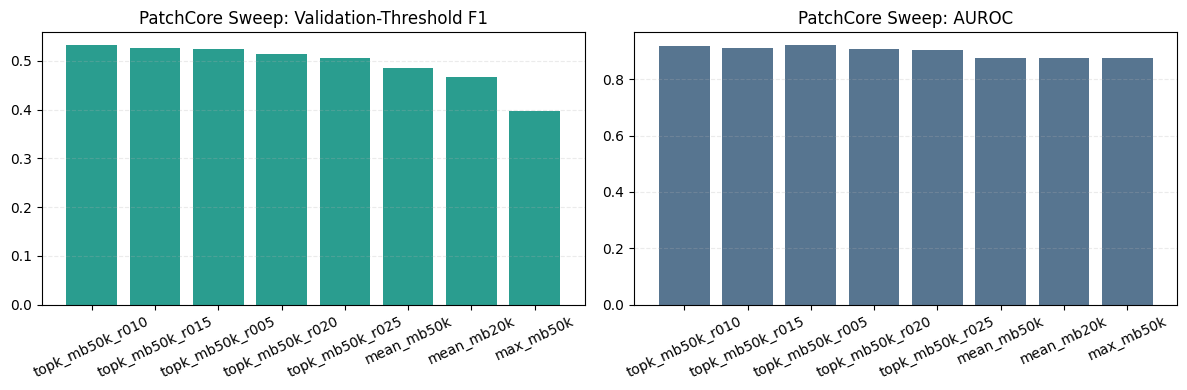

Best variant:
{
  "name": "topk_mb50k_r010",
  "memory_bank_size": 50000,
  "memory_subset_images": 64,
  "patches_per_image": 784,
  "feature_dim": 1536,
  "reduction": "topk_mean",
  "topk_ratio": 0.1,
  "threshold": 0.5296600103378296,
  "precision": 0.4215456674473068,
  "recall": 0.72,
  "f1": 0.5317577548005908,
  "auroc": 0.9169431999999998,
  "auprc": 0.5618547653466999,
  "best_sweep_threshold": 0.5487722158432007,
  "best_sweep_precision": 0.6140350877192983,
  "best_sweep_recall": 0.56,
  "best_sweep_f1": 0.5857740585774058,
  "predicted_anomalies": 427,
  "output_dir": "experiments/anomaly_detection/patchcore/wideresnet50/x64/main/artifacts/patchcore_wideresnet50_multilayer/topk_mb50k_r010",
  "checkpoint_path": "experiments/anomaly_detection/patchcore/wideresnet50/x64/main/artifacts/patchcore_wideresnet50_multilayer/topk_mb50k_r010/patchcore_checkpoint.pt"
}


In [7]:
if not (sweep_ready):
    print('[WARNING] Saved WRN50 PatchCore sweep artifacts are unavailable for this notebook run.')
else:
    combined_results_df = sweep_results_df.copy()

    if "follow_up_results_df" in globals() and not follow_up_results_df.empty:
        combined_results_df = (
            pd.concat([combined_results_df, follow_up_results_df], ignore_index=True)
            .sort_values(["f1", "auroc"], ascending=False)
            .reset_index(drop=True)
        )

    best_row = combined_results_df.iloc[0].to_dict()
    best_checkpoint_src = Path(str(best_row["output_dir"])) / "patchcore_checkpoint.pt"
    best_checkpoint_dst = output_dir / "best_variant_checkpoint.pt"
    if best_checkpoint_src.exists():
        best_checkpoint_dst.write_bytes(best_checkpoint_src.read_bytes())
        best_row["best_checkpoint_path"] = str(best_checkpoint_dst)
        print(f"Saved best-variant checkpoint to {best_checkpoint_dst}")
    else:
        print(f"Best-variant checkpoint missing: {best_checkpoint_src}")
    combined_results_df.to_csv(output_dir / "patchcore_combined_results.csv", index=False)
    (output_dir / "patchcore_sweep_summary.json").write_text(json.dumps({"sweep_variants": [variant["name"] for variant in SWEEP_VARIANTS], "follow_up_variants": [variant["name"] for variant in FOLLOW_UP_VARIANTS] if "FOLLOW_UP_VARIANTS" in globals() else [], "base_output_dir": str(output_dir), "teacher_backbone": "wideresnet50_2", "teacher_layers": TEACHER_LAYERS, "best_variant": best_row}, indent=2), encoding="utf-8")

    display(
        combined_results_df[
            [
                "name",
                "memory_bank_size",
                "reduction",
                "topk_ratio",
                "precision",
                "recall",
                "f1",
                "auroc",
                "auprc",
                "best_sweep_f1",
            ]
        ]
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(combined_results_df["name"], combined_results_df["f1"], color="#2a9d8f")
    axes[0].set_title("PatchCore Sweep: Validation-Threshold F1")
    axes[0].tick_params(axis="x", rotation=25)
    axes[0].grid(axis="y", alpha=0.25, linestyle="--")

    axes[1].bar(combined_results_df["name"], combined_results_df["auroc"], color="#577590")
    axes[1].set_title("PatchCore Sweep: AUROC")
    axes[1].tick_params(axis="x", rotation=25)
    axes[1].grid(axis="y", alpha=0.25, linestyle="--")

    plt.tight_layout()
    plt.show()

    print("Best variant:")
    print(json.dumps(best_row, indent=2))


## Selected Defect Breakdown

This cell loads the best PatchCore variant from the sweep and computes its defect-type recall under the deployed validation-derived threshold.


In [8]:
if not (sweep_ready):
    print('[WARNING] Saved WRN50 PatchCore sweep artifacts are unavailable for this notebook run.')
else:
    # DEFECT_BREAKDOWN_CELL
    summary_path = output_dir / "patchcore_sweep_summary.json"
    if "best_row" not in globals():
        if summary_path.exists():
            best_row = json.loads(summary_path.read_text(encoding="utf-8"))["best_variant"]
        else:
            raise FileNotFoundError(f"Sweep summary not found: {summary_path}. No retraining needed, but rerun the sweep summary cell first.")

    best_variant_name = str(best_row["name"])
    best_threshold = float(best_row["threshold"])
    output_path = output_dir / best_variant_name / "selected_defect_breakdown.csv"

    if not RETRAIN and output_path.exists():
        defect_breakdown_df = pd.read_csv(output_path)
        display(pd.Series(best_row))
        print(f"Best checkpoint: {output_dir / 'best_variant_checkpoint.pt'}")
        display(defect_breakdown_df)
        print(f"Loaded defect breakdown from {output_path}")
    else:
        required_globals = ["output_dir", "test_dataset"]
        missing_globals = [name for name in required_globals if name not in globals()]
        if missing_globals:
            raise RuntimeError(
                "No retraining needed. Rerun the notebook setup/data cells so these objects exist: "
                + ", ".join(missing_globals)
            )

        best_scores_path = output_dir / best_variant_name / "test_scores.csv"
        if not best_scores_path.exists():
            raise FileNotFoundError(f"Test scores not found for best variant: {best_scores_path}")

        best_scores_df = pd.read_csv(best_scores_path).reset_index(drop=True)
        analysis_df = test_dataset.metadata.reset_index(drop=True).copy()
        if len(best_scores_df) != len(analysis_df):
            raise ValueError(f"Length mismatch: scores={len(best_scores_df)} metadata={len(analysis_df)}")
        analysis_df["score"] = best_scores_df["score"]
        analysis_df["predicted_anomaly"] = (analysis_df["score"] >= best_threshold).astype(int)

        defect_breakdown_df = (
            analysis_df.loc[analysis_df["is_anomaly"] == 1]
            .groupby("defect_type")
            .agg(
                count=("defect_type", "size"),
                detected=("predicted_anomaly", "sum"),
                mean_score=("score", "mean"),
                median_score=("score", "median"),
            )
            .reset_index()
        )
        defect_breakdown_df["detected"] = defect_breakdown_df["detected"].astype(int)
        defect_breakdown_df["missed"] = defect_breakdown_df["count"] - defect_breakdown_df["detected"]
        defect_breakdown_df["recall"] = defect_breakdown_df["detected"] / defect_breakdown_df["count"]
        defect_breakdown_df = defect_breakdown_df.sort_values(["recall", "count", "defect_type"], ascending=[True, False, True]).reset_index(drop=True)

        display(pd.Series(best_row))
        print(f"Best checkpoint: {output_dir / 'best_variant_checkpoint.pt'}")
        display(defect_breakdown_df)
        defect_breakdown_df.to_csv(output_path, index=False)
        print(f"Saved defect breakdown to {output_path}")


name                                                      topk_mb50k_r010
memory_bank_size                                                    50000
memory_subset_images                                                   64
patches_per_image                                                     784
feature_dim                                                          1536
reduction                                                       topk_mean
topk_ratio                                                            0.1
threshold                                                         0.52966
precision                                                        0.421546
recall                                                               0.72
f1                                                               0.531758
auroc                                                            0.916943
auprc                                                            0.561855
best_sweep_threshold                  

Best checkpoint: C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\wideresnet50\x64\main\artifacts\patchcore_wideresnet50_multilayer\best_variant_checkpoint.pt


,defect_type,count,detected,mean_score,median_score,missed,recall
0,Scratch,15,8,0.548051,0.534242,7,0.533333
1,Loc,34,19,0.548291,0.534112,15,0.558824
2,Edge-Loc,53,31,0.546760,0.541430,22,0.584906
3,Center,50,31,0.546324,0.533980,19,0.620000
4,Edge-Ring,84,77,0.565509,0.563913,7,0.916667
5,Donut,7,7,0.596891,0.583808,0,1.000000
6,Random,5,5,0.627418,0.623933,0,1.000000
7,Near-full,2,2,0.596443,0.596443,0,1.000000


Loaded defect breakdown from C:\Users\User\Desktop\Term 8\Deep Learning\Project\DeepLearning-Group8\experiments\anomaly_detection\patchcore\wideresnet50\x64\main\artifacts\patchcore_wideresnet50_multilayer\topk_mb50k_r010\selected_defect_breakdown.csv
